# Urban Heat Island Analysis of Nagpur, India Using Earth Observation and Explainable Machine Learning

### Notebook 1 – Study Area Definition and Project Overview

**Author:** Shreya Jariwala

---

## 1. Project Summary

Urban Heat Islands (UHIs) are one of the most visible consequences of rapid urbanization. Replacing vegetation with impervious materials such as asphalt, concrete, and buildings alters the surface energy balance, often leading to significantly higher land surface temperatures.

This project investigates the spatial distribution of Urban Heat Islands (UHIs) across Nagpur, India, using satellite-derived Earth Observation data and machine learning techniques. The objective is to quantify how environmental variables—including vegetation, built-up surfaces, water bodies, and topography—influence urban heat and to develop interpretable machine learning models capable of explaining these spatial patterns.

This notebook introduces the study area, research motivation, datasets, and overall project workflow.

## 2. Research Questions

This project aims to answer the following questions:

1. How is land surface temperature distributed across Nagpur?

2. Which areas experience the strongest Urban Heat Island effect?

3. How do vegetation, built-up density, and water bodies influence land surface temperature?

4. Can machine learning accurately predict urban thermal patterns using environmental variables?

5. Which environmental variables contribute most strongly to urban heat?

## 3. Study Area

The official municipal boundary is downloaded directly from OpenStreetMap using OSMnx.

Using the official administrative boundary ensures that all subsequent spatial analyses are geographically consistent and reproducible.

In [4]:


import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import osmnx as ox
import contextily as ctx

In [5]:
# Project Configuration

CITY = "Nagpur, Maharashtra, India"

CRS = 32644          # UTM Zone 44N

BUFFER = 5000        # metres

YEAR = 2023

print("Study Area:", CITY)
print("Projection:", CRS)

Study Area: Nagpur, Maharashtra, India
Projection: 32644


## 4. Why Nagpur?

Nagpur is located in central India and experiences extremely hot pre-monsoon summers, with daytime temperatures frequently exceeding 45°C.

The city has experienced rapid urban expansion over the past two decades, resulting in increasing impervious surface cover and decreasing vegetation in several regions.

These characteristics make Nagpur an ideal case study for investigating Urban Heat Island dynamics using Earth Observation and GeoAI techniques.

In [6]:
city_boundary = (
    ox.geocode_to_gdf(CITY)
      .to_crs(epsg=CRS)
)

city_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((291852.318 2342411.228, 291890.275 2...",78.995218,21.052974,79.178846,21.231002,246844643,relation,12969115,21.149813,79.082056,boundary,administrative,16,0.580917,city,Nagpur,"Nagpur, Nagpur Urban Taluka, Nagpur, Maharasht..."


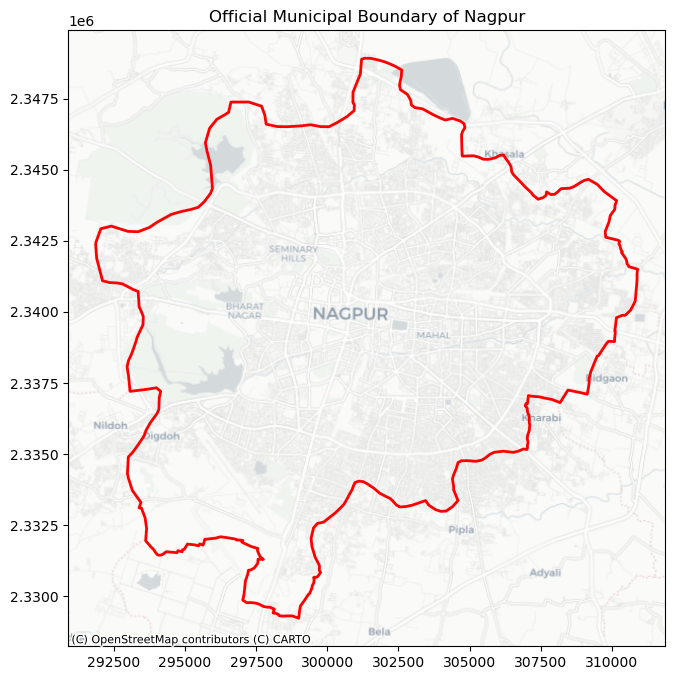

In [7]:
fig, ax = plt.subplots(figsize=(8,8))

city_boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2,
    facecolor="none"
)

ctx.add_basemap(
    ax,
    crs=city_boundary.crs,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Official Municipal Boundary of Nagpur")

plt.show()

In [8]:
minx, miny, maxx, maxy = city_boundary.total_bounds

minx -= BUFFER
miny -= BUFFER
maxx += BUFFER
maxy += BUFFER

print("Bounding Box")
print(minx, miny, maxx, maxy)

Bounding Box
286852.317778924 2324229.6988537307 315914.784229161 2353916.148100074


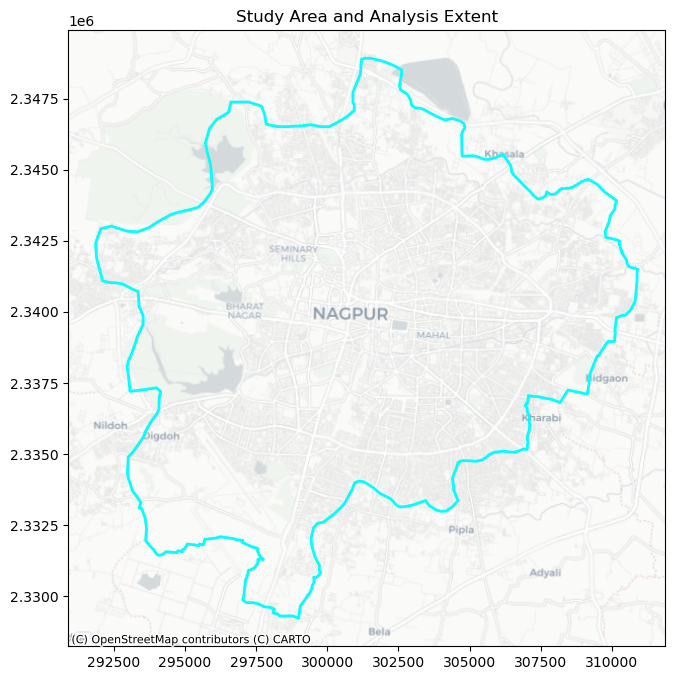

In [9]:
fig, ax = plt.subplots(figsize=(8,8))

city_boundary.plot(
    ax=ax,
    edgecolor="cyan",
    linewidth=2,
    facecolor="none"
)

rect = patches.Rectangle(
    (minx, miny),
    maxx-minx,
    maxy-miny,
    linewidth=2,
    edgecolor="orange",
    linestyle="--",
    facecolor="none"
)

ax.add_patch(rect)

ctx.add_basemap(
    ax,
    crs=city_boundary.crs,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Study Area and Analysis Extent")

plt.show()

## 5. Earth Observation Datasets

This project integrates multiple Earth Observation datasets.

| Dataset | Purpose |
|---------|----------|
| Landsat 8/9 | Land Surface Temperature (LST) |
| Sentinel-2 | NDVI, NDBI and NDWI |
| ESA WorldCover | Land Cover Classification |
| SRTM DEM | Elevation |

## 6. Project Workflow

Official Boundary
        │
        ▼
Satellite Data Acquisition
        │
        ▼
Annual Median Composite
        │
        ▼
Feature Engineering
        │
        ▼
Machine Learning
        │
        ▼
Model Explainability
        │
        ▼
Urban Heat Vulnerability Mapping


## 7. Expected Outputs

By the end of this project, the following products will be generated:

- Land Surface Temperature (LST) map
- NDVI map
- NDBI map
- NDWI map
- Urban Heat Island hotspot map
- Machine learning prediction map
- Feature importance analysis
- Explainable AI (SHAP) interpretation
- Final GeoAI portfolio project

## 8. Summary

This notebook established the spatial foundation for the project by defining the study area and analysis extent.

The next notebook will retrieve Landsat imagery from the Microsoft Planetary Computer, generate annual median composites, and derive Land Surface Temperature (LST) together with key spectral indices required for machine learning.


## 9. Next Notebook

The next notebook focuses on satellite image preprocessing and feature engineering.

The workflow includes:

- Downloading Landsat imagery
- Cloud masking
- Creating annual median composites
- Computing NDVI, NDBI, NDWI, and LST
- Exporting analysis-ready raster datasets

➡️ **Proceed to Notebook 2: Satellite Data Processing and Feature Engineering**